<a href="https://colab.research.google.com/github/RodrigoLMarques/calculo-numerico-unifesp/blob/main/animacao_gaus/animacao_gaus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nome: Rodrigo Lopes Marques

RA: 180385

Turma: Noturno

In [3]:
import textwrap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import FancyBboxPatch
from IPython.display import Image, HTML, display

plt.rcParams["animation.embed_limit"] = 50    # MB, para o player interativo

EPS = 1e-12                                    # abaixo disso o número é tratado como zero

# Cores (fundo, texto) de cada destaque
COR_NORMAL = ("#F7F7F5", "#222222")
COR_PIVO = ("#FAEEDA", "#854F0B")              # pivô
COR_LINHA = ("#E6F1FB", "#0C447C")             # linha sendo alterada
COR_ZERADO = ("#EAF3DE", "#27500A")            # elemento que acabou de ser zerado
COR_TROCA = ("#EEEDFE", "#3C3489")             # linhas trocadas no pivoteamento
COR_APAGADO = "#B4B2A9"                        # zeros já obtidos abaixo da diagonal

SUB = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")


def sub(k):
    """Índice subscrito começando em 1: sub(0) -> '₁'."""
    return str(k + 1).translate(SUB)


def fmt(v, casas=4):
    """Número com vírgula decimal, sem zeros sobrando e com sinal de menos tipográfico."""
    if abs(v) < EPS:
        v = 0.0
    s = f"{v:.{casas}f}".rstrip("0").rstrip(".")
    if s in ("-0", ""):
        s = "0"
    return s.replace(".", ",").replace("-", "−")


def par(v):
    """Coloca parênteses em números negativos (para usar dentro de expressões)."""
    return f"({fmt(v)})" if v < -EPS else fmt(v)


def fmt_cient(v):
    """Notação científica curta: 1,2e−15 (zero exato vira 0)."""
    if v == 0:
        return "0"
    return f"{v:.1e}".replace(".", ",").replace("-", "−")

In [4]:
def eliminacao_gauss(A, b, pivoteamento=False):
    """Resolve Ax = b por eliminação de Gauss + substituição regressiva,
    guardando cada passo para a animação.

    Devolve um dicionário com:
    x           solução (None se falhar)
    sucesso     True/False
    mensagem    descrição do resultado
    U           matriz aumentada triangular [U | c]
    trocas      número de trocas de linha feitas
    passos      lista de passos (usada por animar_eliminacao)
    """
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float).reshape(-1)
    n = len(b)
    M = np.column_stack([A, b])                # matriz aumentada [A | b]
    passos = []
    trocas = 0
    x = [None] * n

    def registrar(fase, op, txt, **destaques):
        passos.append({"M": M.copy(), "fase": fase, "op": op, "txt": txt,
                       "x": list(x), **destaques})

    def falhar(msg):
        registrar("Falha", "Sem solução única", msg)
        return {"x": None, "sucesso": False, "mensagem": msg, "U": M.copy(),
                "trocas": trocas, "passos": passos}

    registrar("Sistema original", "[A | b]",
              "Matriz aumentada do sistema. O objetivo é zerar tudo abaixo da diagonal principal.")

    # ---- Escalonamento
    for k in range(n - 1):
        fase = f"Escalonamento · coluna {k + 1}"

        if pivoteamento:
            p = k + int(np.argmax(np.abs(M[k:, k])))
            if abs(M[p, k]) < EPS:
                return falhar(f"Coluna {k + 1} só tem zeros da diagonal para baixo: "
                              "a matriz é singular.")
            if p != k:
                M[[k, p]] = M[[p, k]]
                trocas += 1
                registrar(fase, f"L{sub(k)} ↔ L{sub(p)}",
                          f"Pivoteamento parcial: a linha com o maior |a{sub(p)}{sub(k)}| "
                          f"na coluna {k + 1} sobe para a posição do pivô.",
                          troca=(k, p))
        elif abs(M[k, k]) < EPS:
            return falhar(f"Pivô nulo em a{sub(k)}{sub(k)}. Sem pivoteamento não dá para "
                          "continuar; rode com pivoteamento=True.")

        pivo = M[k, k]
        registrar(fase, f"pivô a{sub(k)}{sub(k)} = {fmt(pivo)}",
                  f"A linha L{sub(k)} vira a linha pivô e vai ser usada para zerar "
                  f"os elementos abaixo de a{sub(k)}{sub(k)}.",
                  pivo=(k, k), linha_pivo=k)

        for i in range(k + 1, n):
            a_ik = M[i, k]
            m = a_ik / pivo
            if abs(a_ik) < EPS:
                registrar(fase, f"m{sub(i)}{sub(k)} = 0  →  L{sub(i)} não muda",
                          f"a{sub(i)}{sub(k)} já é zero, então não há nada a fazer nessa linha.",
                          pivo=(k, k), linha_pivo=k, linha=i, zerado=(i, k))
                continue
            M[i, k:] = M[i, k:] - m * M[k, k:]
            M[i, k] = 0.0                      # evita resto de arredondamento
            registrar(fase, f"L{sub(i)} ← L{sub(i)} − {par(m)}·L{sub(k)}",
                      f"Multiplicador m{sub(i)}{sub(k)} = a{sub(i)}{sub(k)} / a{sub(k)}{sub(k)} "
                      f"= {fmt(a_ik)} / {par(pivo)} = {fmt(m)}.",
                      pivo=(k, k), linha_pivo=k, linha=i, zerado=(i, k))

    if abs(M[n - 1, n - 1]) < EPS:
        return falhar(f"Pivô nulo em a{sub(n - 1)}{sub(n - 1)} depois do escalonamento: "
                      "a matriz é singular.")

    registrar("Sistema triangular", "U · x = c",
              "A matriz ficou triangular superior. Agora a solução sai de baixo para cima, "
              "pela substituição regressiva.")

    # ---- Substituição regressiva
    for i in range(n - 1, -1, -1):
        soma = M[i, n]
        expr = fmt(M[i, n])
        tem_termo = False
        for j in range(i + 1, n):
            soma -= M[i, j] * x[j]
            if abs(M[i, j]) > EPS:
                expr += f" − {par(M[i, j])}·{par(x[j])}"
                tem_termo = True
        x[i] = soma / M[i, i]
        numerador = f"({expr})" if tem_termo else expr
        txt = ("A última linha tem uma incógnita só, então é resolvida direto." if i == n - 1
               else "Usa os valores já encontrados nas linhas de baixo e isola a incógnita da diagonal.")
        registrar("Substituição regressiva",
                  f"x{sub(i)} = {numerador} / {par(M[i, i])} = {fmt(x[i])}",
                  txt, linha=i, diag=i)

    x = np.array(x)
    residuo = np.linalg.norm(A @ x - b)
    registrar("Solução", "x = (" + "; ".join(fmt(v) for v in x) + ")",
              f"Conferência: resíduo ‖Ax − b‖ = {fmt_cient(residuo)}.")
    return {"x": x, "sucesso": True,
            "mensagem": f"Solução encontrada ({trocas} troca(s) de linha).",
            "U": M.copy(), "trocas": trocas, "passos": passos}

In [5]:
def desenhar_passo(fig, passo, n, indice, total):
    """Desenha um passo da eliminação na figura (limpa a figura antes)."""
    fig.clf()
    M = passo["M"]

    # Layout da matriz, em unidades do eixo
    larg_rot, larg_cel, gap, alt_cel = 0.9, 1.5, 0.35, 0.9
    x_col = [larg_rot + j * larg_cel for j in range(n)] + [larg_rot + n * larg_cel + gap]
    largura = x_col[-1] + larg_cel
    altura = (n + 1) * alt_cel

    ax = fig.add_axes([0.04, 0.42, 0.92, 0.5])
    ax.set_xlim(-0.2, largura + 0.2)
    ax.set_ylim(-0.1, altura + 0.1)
    ax.set_aspect("equal")
    ax.axis("off")

    # Cabeçalho
    y_cab = altura - alt_cel / 2
    for j in range(n):
        ax.text(x_col[j] + larg_cel / 2, y_cab, f"x{sub(j)}", ha="center", va="center",
                fontsize=12, color="#666666")
    ax.text(x_col[n] + larg_cel / 2, y_cab, "b", ha="center", va="center",
            fontsize=12, color="#666666")

    troca = passo.get("troca")
    for i in range(n):
        y = altura - (i + 1.5) * alt_cel
        ax.text(larg_rot - 0.25, y, f"L{sub(i)}", ha="right", va="center",
                fontsize=12, color="#666666")
        for j in range(n + 1):
            v = M[i, j]
            fundo, cor, peso = *COR_NORMAL, "normal"
            if passo.get("zerado") == (i, j):
                fundo, cor, peso = *COR_ZERADO, "bold"
            elif passo.get("pivo") == (i, j) or (passo.get("diag") == i and j == i):
                fundo, cor, peso = *COR_PIVO, "bold"
            elif troca and i in troca:
                fundo, cor = COR_TROCA
            elif passo.get("linha") == i:
                fundo, cor = COR_LINHA
            elif j < i and abs(v) < EPS:
                cor = COR_APAGADO
            borda = "#444444" if passo.get("linha_pivo") == i else "none"
            ax.add_patch(FancyBboxPatch((x_col[j] + 0.06, y - alt_cel / 2 + 0.06),
                                        larg_cel - 0.12, alt_cel - 0.12,
                                        boxstyle="round,pad=0,rounding_size=0.12",
                                        facecolor=fundo, edgecolor=borda, linewidth=1))
            ax.text(x_col[j] + larg_cel - 0.2, y, fmt(v), ha="right", va="center",
                    fontsize=13, color=cor, fontweight=peso, family="DejaVu Sans Mono")

    # Barra vertical separando A de b
    x_sep = x_col[n] - gap / 2
    ax.plot([x_sep, x_sep], [0.05, altura - alt_cel], color="#888888", lw=1.2)

    # Fase e contador
    fig.text(0.04, 0.955, passo["fase"], fontsize=11, color="#666666", va="top")
    fig.text(0.96, 0.955, f"passo {indice + 1} de {total}", fontsize=11, color="#666666",
             va="top", ha="right")

    # Operação e explicação
    fig.text(0.5, 0.33, passo["op"], ha="center", va="center", fontsize=16,
             color="#111111")
    fig.text(0.5, 0.25, textwrap.fill(passo["txt"], 95), ha="center", va="top",
             fontsize=11, color="#555555", linespacing=1.5)

    # Incógnitas já encontradas
    fichas = [f"x{sub(i)} = {'?' if v is None else fmt(v)}" for i, v in enumerate(passo["x"])]
    fig.text(0.5, 0.07, "     ".join(fichas), ha="center", va="center", fontsize=12,
             family="DejaVu Sans Mono", color="#27500A" if None not in passo["x"] else "#555555",
             bbox=dict(boxstyle="round,pad=0.5", fc="#F7F7F5", ec="none"))


def animar_eliminacao(r, arquivo=None, fps=0.8, pausa_final=3, dpi=90):
    """Gera a animação a partir do resultado r de eliminacao_gauss.

    arquivo      caminho do GIF (None = não salva)
    fps          quadros por segundo (0,8 = 1,25 s por passo)
    pausa_final  quantas vezes o último quadro se repete
    Devolve o objeto FuncAnimation (para usar com HTML(anim.to_jshtml())).
    """
    passos = r["passos"]
    n = passos[0]["M"].shape[0]
    total = len(passos)
    fig = plt.figure(figsize=(max(8, 1.5 * n + 4), 6.2), dpi=dpi)

    def atualizar(q):
        i = min(q, total - 1)
        desenhar_passo(fig, passos[i], n, i, total)
        return []

    anim = FuncAnimation(fig, atualizar, frames=total + pausa_final,
                         interval=1000 / fps, blit=False)
    if arquivo:
        anim.save(arquivo, writer=PillowWriter(fps=fps))
    plt.close(fig)                             # evita que o Colab mostre uma figura estática extra
    return anim

Solução encontrada (0 troca(s) de linha). x = [ 2.  3. -1.]
numpy.linalg.solve: [ 2.  3. -1.]


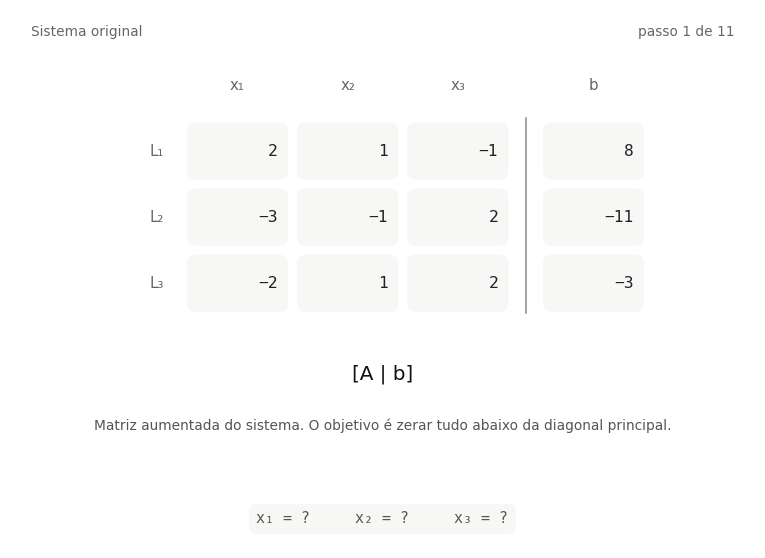

In [6]:
A1 = [[ 2,  1, -1],
      [-3, -1,  2],
      [-2,  1,  2]]
b1 = [8, -11, -3]

r1 = eliminacao_gauss(A1, b1)
print(r1["mensagem"], "x =", r1["x"])
print("numpy.linalg.solve:", np.linalg.solve(A1, b1))

animar_eliminacao(r1, "eliminacao_gauss.gif")
display(Image(filename="eliminacao_gauss.gif"))

Sem pivoteamento: Pivô nulo em a₁₁. Sem pivoteamento não dá para continuar; rode com pivoteamento=True.
Com pivoteamento: Solução encontrada (1 troca(s) de linha). x = [1. 2. 3.]


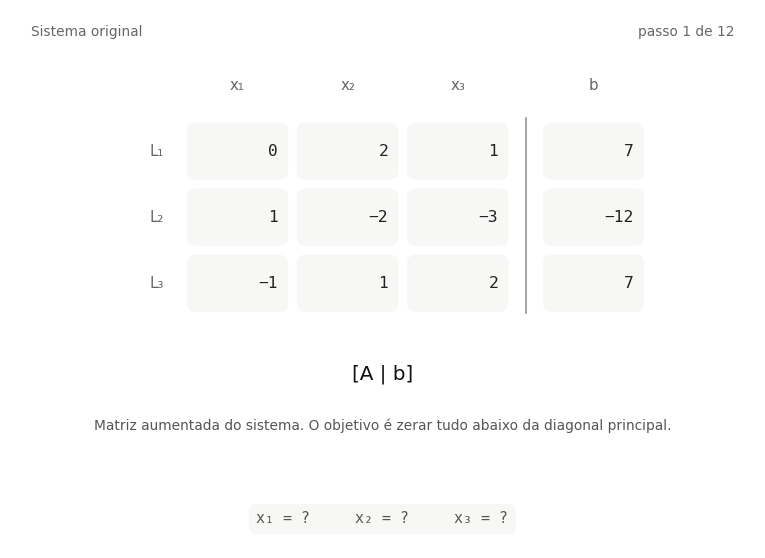

In [7]:
A2 = [[ 0,  2,  1],
      [ 1, -2, -3],
      [-1,  1,  2]]
b2 = [7, -12, 7]

sem = eliminacao_gauss(A2, b2, pivoteamento=False)
print("Sem pivoteamento:", sem["mensagem"])

r2 = eliminacao_gauss(A2, b2, pivoteamento=True)
print("Com pivoteamento:", r2["mensagem"], "x =", r2["x"])

animar_eliminacao(r2, "eliminacao_gauss_pivoteamento.gif")
display(Image(filename="eliminacao_gauss_pivoteamento.gif"))

In [8]:
anim = animar_eliminacao(r1)
HTML(anim.to_jshtml())